In [101]:
# -----------------------------
# IMPORTS
# -----------------------------

from pathlib import Path
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from datetime import datetime


In [102]:
# -----------------------------
# TEST PATHS
# -----------------------------

spu_path = Path("data/calibration/background_550PM_feb26_213PM_mar3.spu")
test_csv_path = Path("data/calibration/TESTFILE_FOR_CONVERSION_BGND.csv")  # CSV file used as test

print("SPU exists:", spu_path.exists(), spu_path)
print("CSV exists:", csv_path.exists(), csv_path)

SPU exists: True data/calibration/background_550PM_feb26_213PM_mar3.spu
CSV exists: True data/calibration/TESTFILE_FOR_CONVERSION_BGND.csv


In [103]:
# -----------------------------
# SPU READER & FOOTER METADATA PARSING
# -----------------------------
def read_spu(filepath: str | Path):
    """
    UCS-20 .spu format:
      bytes 0..3 : uint32 little-endian gain (#channels)
      bytes 4..  : gain * uint32 little-endian counts
      rest       : metadata/footer (binary + embedded ASCII)
    """
    filepath = Path(filepath)
    data = filepath.read_bytes()

    gain = int.from_bytes(data[0:4], "little")
    start = 4
    end = start + gain * 4

    counts = np.frombuffer(data[start:end], dtype="<u4").astype(np.int64)
    footer = data[end:]
    return gain, counts, footer


def _extract_ascii_strings(blob: bytes, min_len: int = 4):
    """Return printable ASCII runs embedded in a binary blob."""
    out = []
    cur = []
    start = None
    for i, b in enumerate(blob):
        if 32 <= b <= 126:
            if start is None:
                start = i
            cur.append(chr(b))
        else:
            if start is not None and len(cur) >= min_len:
                out.append("".join(cur))
            start = None
            cur = []
    if start is not None and len(cur) >= min_len:
        out.append("".join(cur))
    return out


def parse_spu_footer_metadata(footer: bytes):
    """
    Extract the parts we care about from the binary footer:
      - Start Time / End Time in UCS-export style date string
      - Spectrum Name (heuristic, e.g. Cs-137)
    """
    meta = {}
    text = footer.decode("latin-1", errors="ignore")

    # Example format (from your UCS export):
    # Thursday, February 26, 2026, 17:44:33
    date_re = (
        r'((?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday),\s+'
        r'[A-Za-z]+\s+\d{1,2},\s+\d{4},\s+\d{2}:\d{2}:\d{2})'
    )
    dates = re.findall(date_re, text)
    if len(dates) >= 1:
        meta["Start Time"] = dates[0]
    if len(dates) >= 2:
        meta["End Time"] = dates[1]

    # Spectrum name heuristic (best-effort)
    for s in _extract_ascii_strings(footer, min_len=4):
        if re.fullmatch(r"[A-Za-z]{1,3}-\d{2,3}", s):
            meta["Spectrum Name"] = s
            break

    return meta


def _elapsed_real_seconds_from_meta(meta: dict):
    """Compute elapsed real time from Start/End strings if possible."""
    if "Start Time" not in meta or "End Time" not in meta:
        return ""
    try:
        fmt = "%A, %B %d, %Y, %H:%M:%S"
        t0 = datetime.strptime(meta["Start Time"], fmt)
        t1 = datetime.strptime(meta["End Time"], fmt)
        return f"{(t1 - t0).total_seconds():.2f}"
    except Exception:
        return ""


In [104]:
# -----------------------------
# UCS-STYLE CSV WRITER & SINGLE-FILE CONVERTER
# -----------------------------

def write_ucs_style_csv(
    csv_file: str | Path,
    *,
    gain: int,
    counts: np.ndarray,
    meta: dict,
    original_name: str = ""
):
    """
    Write a UCS-export-like CSV:
      - header section with key fields
      - then 'Channel Data:' + 'Channel,Energy,Counts'
      - Energy left blank
    """
    csv_file = Path(csv_file)
    csv_file.parent.mkdir(parents=True, exist_ok=True)

    spectrum_name = meta.get("Spectrum Name", "")
    start_time = meta.get("Start Time", "")
    end_time = meta.get("End Time", "")
    elapsed_real = _elapsed_real_seconds_from_meta(meta)

    with open(csv_file, "w", newline="") as f:
        # UCS-ish header block (matches your sample structure closely)
        f.write(f"Spectrum Name:,{spectrum_name}\n")
        f.write("Description:\n")
        f.write("Student ID:\n")
        f.write("Detector Used:\n")
        f.write("Comments:\n")
        f.write("Acquisition Mode:,PHA Pre-Amp\n")
        f.write("High Voltage:,0\n")
        f.write(f"Conversion Gain:,{gain}\n")
        f.write("Coarse Gain:,\n")
        f.write("Fine Gain:,\n")
        f.write("Upper Discriminator:,\n")
        f.write("Lower Discriminator:,\n")
        f.write(f"Calibration Coefficients:Elapsed Real Time:,{elapsed_real}\n")
        f.write("Elapsed Live Time:,\n")
        f.write(f"Start Time:,{start_time}\n")
        f.write(f"End Time:,{end_time}\n")
        f.write("ROIs:\n")
        f.write("ROI:,Low,High,Gross,Net,FWHM,Centroid\n")
        f.write("\n\n")
        f.write("Channel Data:\n")
        f.write("Channel,Energy,Counts\n")

        for ch, ct in enumerate(counts):
            f.write(f"{ch},,{int(ct)}\n")


def spu_to_csv(spu_file: str | Path, csv_file: str | Path):
    """Convert one .spu -> UCS-style .csv."""
    spu_file = Path(spu_file)
    gain, counts, footer = read_spu(spu_file)
    meta = parse_spu_footer_metadata(footer)
    write_ucs_style_csv(csv_file, gain=gain, counts=counts, meta=meta, original_name=spu_file.name)
    return Path(csv_file)

In [105]:
# -----------------------------
# TREE REPLICATION
# -----------------------------

def clear_directory_tree(root: str | Path):
    """Delete an entire directory tree if it exists."""
    root = Path(root)
    if root.exists():
        shutil.rmtree(root)


def convert_data_tree(
    data_root: str | Path = "data",
    processed_root: str | Path = "processed_data",
    clear_processed_root: bool = True
):
    """
    Replicate the original 'data' tree into 'processed_data':
      - .spu files are converted to .csv (same relative path, suffix replaced)
      - all other files are copied byte-for-byte
    Also (optionally) clears processed_root before rewriting.
    """
    data_root = Path(data_root)
    processed_root = Path(processed_root)

    if clear_processed_root:
        clear_directory_tree(processed_root)

    processed_root.mkdir(parents=True, exist_ok=True)

    files = list(data_root.rglob("*"))
    for f in files:
        if f.is_dir():
            continue

        rel = f.relative_to(data_root)
        out = processed_root / rel

        if f.suffix.lower() == ".spu":
            out = out.with_suffix(".csv")
            print("Converting:", f)
            spu_to_csv(f, out)
        else:
            out.parent.mkdir(parents=True, exist_ok=True)
            out.write_bytes(f.read_bytes())

    print("\nFinished conversion.")

In [106]:
# -----------------------------
# LOADERS & PLOTS
# -----------------------------

def load_spu_ucs20(filepath: str | Path):
    gain, counts, _footer = read_spu(filepath)
    ch = np.arange(gain, dtype=int)
    return ch, counts


def load_ucs_export_csv(filepath: str | Path):
    """
    Loads UCS-exported-style CSV:
      ...
      Channel Data:
      Channel,Energy,Counts
      0,,0
      ...
    """
    filepath = Path(filepath)
    lines = filepath.read_text(errors="ignore").splitlines()
    header_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("Channel,Energy,Counts"):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f"Could not find 'Channel,Energy,Counts' in {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx)
    ch = df["Channel"].to_numpy().astype(int)
    ct = df["Counts"].to_numpy().astype(np.int64)
    return ch, ct


def plot_overlay_and_residuals(ch_a, y_a, ch_b, y_b, title_a="A", title_b="B", title="Comparison"):
    min_ch = max(int(ch_a.min()), int(ch_b.min()))
    max_ch = min(int(ch_a.max()), int(ch_b.max()))
    grid = np.arange(min_ch, max_ch + 1)

    if np.array_equal(ch_a, np.arange(len(ch_a))):
        ya = y_a[grid]
    else:
        idx_a = {int(c): i for i, c in enumerate(ch_a)}
        ya = np.array([y_a[idx_a[int(c)]] if int(c) in idx_a else 0 for c in grid], dtype=float)

    if np.array_equal(ch_b, np.arange(len(ch_b))):
        yb = y_b[grid]
    else:
        idx_b = {int(c): i for i, c in enumerate(ch_b)}
        yb = np.array([y_b[idx_b[int(c)]] if int(c) in idx_b else 0 for c in grid], dtype=float)

    diff = ya - yb
    corr = np.corrcoef(ya, yb)[0, 1] if len(grid) > 2 else np.nan
    print(f"{title}: corr={corr:.12f} | max_abs_diff={np.max(np.abs(diff)):.6g} | nonzero={int(np.sum(diff!=0))}")

    # Linear overlay
    plt.figure(figsize=(12, 4))
    plt.plot(grid, ya, linewidth=1, label=title_a)
    plt.plot(grid, yb, linewidth=1, alpha=0.75, label=title_b)
    plt.xlabel("Channel"); plt.ylabel("Counts")
    plt.title(f"{title} — Overlay (linear)")
    plt.legend()
    plt.show()

    # Log overlay
    plt.figure(figsize=(12, 4))
    plt.plot(grid, np.maximum(ya, 1), linewidth=1, label=title_a)
    plt.plot(grid, np.maximum(yb, 1), linewidth=1, alpha=0.75, label=title_b)
    plt.xlabel("Channel"); plt.ylabel("Counts (log)")
    plt.yscale("log")
    plt.title(f"{title} — Overlay (log)")
    plt.legend()
    plt.show()

    # Residuals
    plt.figure(figsize=(12, 4))
    plt.plot(grid, diff, linewidth=1)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Channel"); plt.ylabel(f"{title_a} - {title_b}")
    plt.title(f"{title} — Residuals")
    plt.show()

    return grid, diff

In [107]:
# -----------------------------
# HEADER TEST HELPERS
# -----------------------------

def parse_ucs_csv_header_fields(csv_path: str | Path):
    """
    Parse top header block from UCS-style CSV into dict of fields.
    Stops at 'Channel Data:' line.
    """
    csv_path = Path(csv_path)
    lines = csv_path.read_text(errors="ignore").splitlines()

    fields = {}
    for ln in lines:
        if ln.strip().startswith("Channel Data:"):
            break

        # We want lines that look like "Key:,Value"
        if ":," in ln:
            key, val = ln.split(":,", 1)
            fields[key.strip() + ":"] = val.strip()
        else:
            # fallback: allow "Key,Value" for some weird lines
            parts = ln.split(",", 1)
            if len(parts) == 2 and parts[0].strip().endswith(":"):
                fields[parts[0].strip()] = parts[1].strip()

    return fields


def assert_field_equal(name: str, a: str, b: str):
    if (a or "") != (b or ""):
        raise AssertionError(f"[HEADER FAIL] {name} mismatch:\n  A: {a}\n  B: {b}")

In [108]:
# -----------------------------
# TESTS (SPU vs sample CSV; converted vs sample; counts)
# -----------------------------

def test_spu_footer_times_match_sample_csv(spu_path: str | Path, ucs_sample_csv: str | Path):
    gain, counts, footer = read_spu(spu_path)
    meta = parse_spu_footer_metadata(footer)

    sample_fields = parse_ucs_csv_header_fields(ucs_sample_csv)

    spu_start = meta.get("Start Time", "")
    spu_end   = meta.get("End Time", "")

    csv_start = sample_fields.get("Start Time:", "")
    csv_end   = sample_fields.get("End Time:", "")

    print("SPU parsed Start:", spu_start)
    print("CSV sample Start:", csv_start)
    print("SPU parsed End:", spu_end)
    print("CSV sample End:", csv_end)

    assert_field_equal("Start Time", spu_start, csv_start)
    assert_field_equal("End Time", spu_end, csv_end)

    print("[PASS] SPU footer Start/End times match UCS-export CSV.")


def test_converted_csv_header_matches_sample(csv_converted: str | Path, ucs_sample_csv: str | Path):
    conv_fields = parse_ucs_csv_header_fields(csv_converted)
    samp_fields = parse_ucs_csv_header_fields(ucs_sample_csv)

    keys_to_check = [
        "Conversion Gain:",
        "Start Time:",
        "End Time:",
        "Spectrum Name:",
    ]

    for k in keys_to_check:
        a = conv_fields.get(k, "")
        b = samp_fields.get(k, "")
        print(f"{k}  converted='{a}' | sample='{b}'")

        # Spectrum Name may be missing in SPU footer; don't hard-fail if either is empty
        if k == "Spectrum Name:" and (a == "" or b == ""):
            continue

        assert_field_equal(k, a, b)

    print("[PASS] Converted CSV header matches UCS-export header for key fields.")


def test_counts_match_spu_and_sample_csv(spu_path: str | Path, ucs_sample_csv: str | Path, make_plots=True):
    ch_spu, ct_spu = load_spu_ucs20(spu_path)
    ch_csv, ct_csv = load_ucs_export_csv(ucs_sample_csv)

    ok = (len(ct_spu) == len(ct_csv)) and np.array_equal(ch_spu, ch_csv) and np.array_equal(ct_spu, ct_csv)
    if not ok:
        n = min(len(ct_spu), len(ct_csv))
        diff = ct_spu[:n] - ct_csv[:n]
        raise AssertionError(
            "[COUNTS FAIL] SPU counts do not match UCS sample counts.\n"
            f"  len(spu)={len(ct_spu)} len(csv)={len(ct_csv)}\n"
            f"  max_abs_diff={int(np.max(np.abs(diff)))} nonzero={int(np.sum(diff!=0))}"
        )

    print("[PASS] SPU decoded counts match UCS-export sample counts exactly.")

    if make_plots:
        plot_overlay_and_residuals(
            ch_spu, ct_spu,
            ch_csv, ct_csv,
            title_a="SPU decoded (truth)",
            title_b="UCS export CSV",
            title="SPU vs UCS Export"
        )


def test_counts_match_spu_and_converted_csv(spu_path: str | Path, converted_csv: str | Path, make_plots=True):
    ch_spu, ct_spu = load_spu_ucs20(spu_path)
    ch_out, ct_out = load_ucs_export_csv(converted_csv)

    ok = (len(ct_spu) == len(ct_out)) and np.array_equal(ch_spu, ch_out) and np.array_equal(ct_spu, ct_out)
    if not ok:
        n = min(len(ct_spu), len(ct_out))
        diff = ct_spu[:n] - ct_out[:n]
        raise AssertionError(
            "[COUNTS FAIL] SPU counts do not match converted CSV counts.\n"
            f"  len(spu)={len(ct_spu)} len(out)={len(ct_out)}\n"
            f"  max_abs_diff={int(np.max(np.abs(diff)))} nonzero={int(np.sum(diff!=0))}"
        )

    print("[PASS] SPU decoded counts match converted CSV counts exactly.")

    if make_plots:
        plot_overlay_and_residuals(
            ch_spu, ct_spu,
            ch_out, ct_out,
            title_a="SPU decoded (truth)",
            title_b="Converted CSV",
            title="SPU vs Converted"
        )


def run_all_header_and_counts_tests(
    spu_path: str | Path,
    ucs_sample_csv: str | Path,
    out_converted_csv: str | Path,
    make_plots=True
):
    spu_path = Path(spu_path)
    ucs_sample_csv = Path(ucs_sample_csv)
    out_converted_csv = Path(out_converted_csv)

    # 1) SPU footer time extraction sanity vs sample CSV
    test_spu_footer_times_match_sample_csv(spu_path, ucs_sample_csv)

    # 2) Convert single file -> out_converted_csv
    print("\nConverting SPU ->", out_converted_csv)
    spu_to_csv(spu_path, out_converted_csv)
    print("Wrote:", out_converted_csv, "| exists:", out_converted_csv.exists())

    # 3) Converted header vs sample header
    test_converted_csv_header_matches_sample(out_converted_csv, ucs_sample_csv)

    # 4) Counts tests
    test_counts_match_spu_and_sample_csv(spu_path, ucs_sample_csv, make_plots=make_plots)
    test_counts_match_spu_and_converted_csv(spu_path, out_converted_csv, make_plots=make_plots)

    print("\n=== ALL TESTS PASSED ===")

In [109]:
# -----------------------------
# WHOTS (SPU vs sample CSV; converted vs sample; counts)E-TREE VERIFICATION
# -----------------------------

def verify_processed_tree(
    data_root: str | Path = "data",
    processed_root: str | Path = "processed_data",
    max_plots: int = 25,
    only_mismatches: bool = False
):
    """
    Verifies that for every .spu file in data_root there is a matching .csv in processed_root
    and that counts match exactly.

    Also prints overlay+residual plots for up to `max_plots` files (or mismatches only).
    """
    data_root = Path(data_root)
    processed_root = Path(processed_root)

    spu_files = sorted(data_root.rglob("*.spu"))
    if not spu_files:
        raise ValueError(f"No .spu files found under {data_root}")

    n_ok = 0
    n_bad = 0
    plotted = 0

    for spu in spu_files:
        rel = spu.relative_to(data_root)
        out_csv = (processed_root / rel).with_suffix(".csv")

        if not out_csv.exists():
            print("MISSING CSV:", out_csv)
            n_bad += 1
            continue

        ch_spu, ct_spu = load_spu_ucs20(spu)
        ch_out, ct_out = load_ucs_export_csv(out_csv)

        ok = (len(ct_spu) == len(ct_out)) and np.array_equal(ch_spu, ch_out) and np.array_equal(ct_spu, ct_out)

        if ok:
            n_ok += 1
        else:
            n_bad += 1
            print("MISMATCH:", rel)
            print("  len(spu), len(csv):", len(ct_spu), len(ct_out))
            n = min(len(ct_spu), len(ct_out))
            diff = ct_spu[:n] - ct_out[:n]
            print("  max_abs_diff:", int(np.max(np.abs(diff))), "nonzero:", int(np.sum(diff != 0)))

        if plotted < max_plots and ((not only_mismatches) or (not ok)):
            plot_overlay_and_residuals(
                ch_spu, ct_spu,
                ch_out, ct_out,
                title_a="SPU decoded (truth)",
                title_b="processed CSV",
                title=f"Verify {rel.as_posix()}"
            )
            plotted += 1

    print("\n=== Verification summary ===")
    print("Total SPU files:", len(spu_files))
    print("OK:", n_ok)
    print("BAD:", n_bad)
    if n_bad == 0:
        print("PASS: processed_data appears to match data exactly for all .spu files.")
    else:
        print("FAIL: mismatches detected (see messages above).")

Converting: data/cs gain setting/Cs_possible_calcurve_feb_24.spu
Converting: data/cs gain setting/Cs_trial_feb_19.spu
Converting: data/calibration/background_550PM_feb26_213PM_mar3.spu
Converting: data/data/Co57_runs_overnight/Co57_22.2C_preamp0_feb25_overnight.spu
Converting: data/data/Al thickness/Al_16cmpmt_2.3cmthick.spu
Converting: data/data/Al thickness/Al_16cmpmt_14.7cmthick.spu
Converting: data/data/Al thickness/Al_16cmpmt_1.3cmthick.spu
Converting: data/data/Pb thickness/Pb_15.3cmpmt_4.8cmthick.spu
Converting: data/data/feb_26/na22/Na_22.6C_feb26_run1.spu
Converting: data/data/feb_26/cs137/Cs_22.4C_feb26_run1.spu
Converting: data/data/feb_26/co60/Co_22.8C_feb26_run1.spu
Converting: data/data/feb_24/Na22/Na_22.5C_feb24_run1.spu
Converting: data/data/feb_24/co60/Co_22.4C_feb24_run1.spu
Converting: data/calibration/daily/Cs_22.4C_preamp0_feb26.spu
Converting: data/calibration/daily/Co60_22.5C_preamp100_mar3.spu
Converting: data/calibration/daily/Co60_22.4C_preamp100_feb26.spu
Con

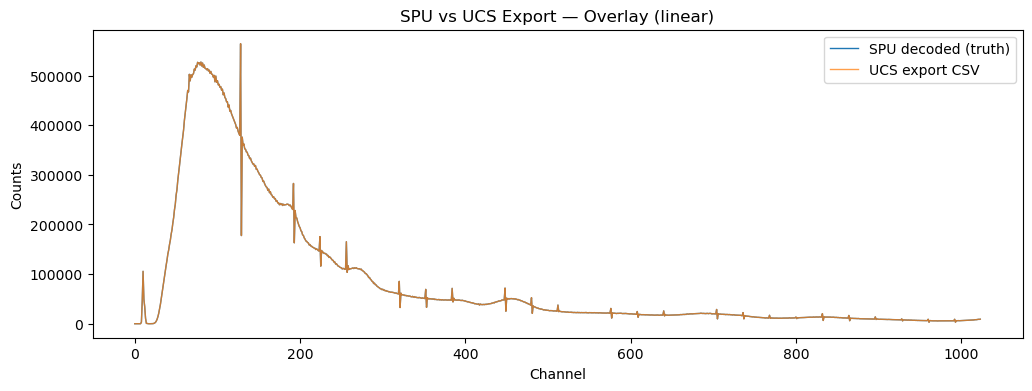

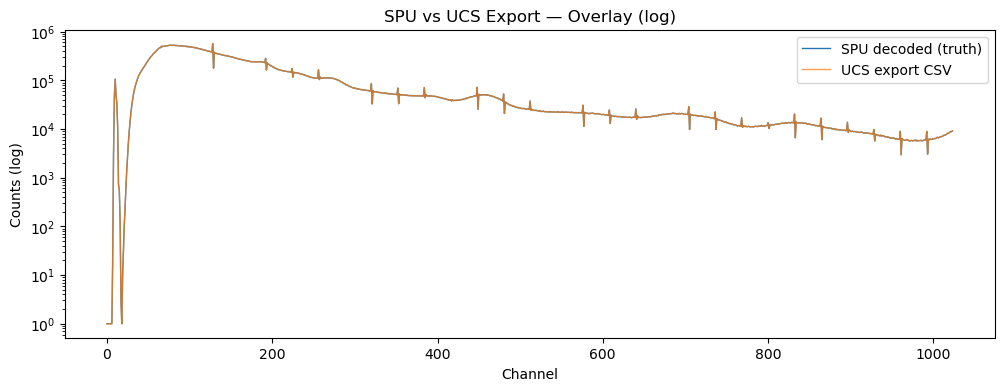

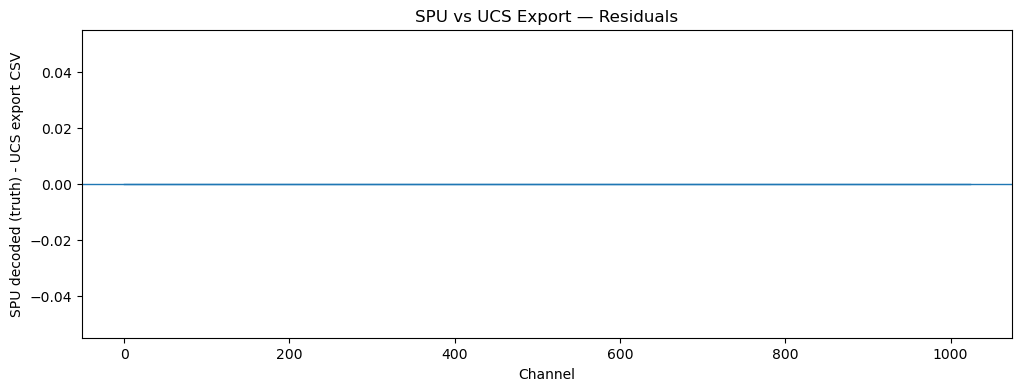

[PASS] SPU decoded counts match converted CSV counts exactly.
SPU vs Converted: corr=1.000000000000 | max_abs_diff=0 | nonzero=0


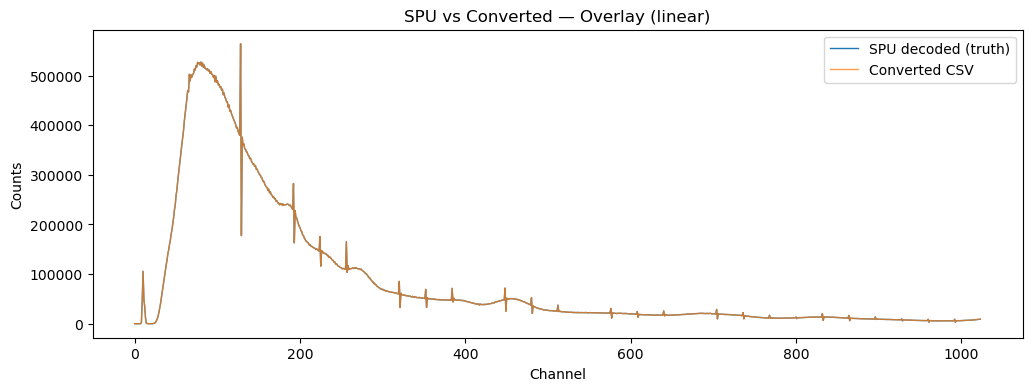

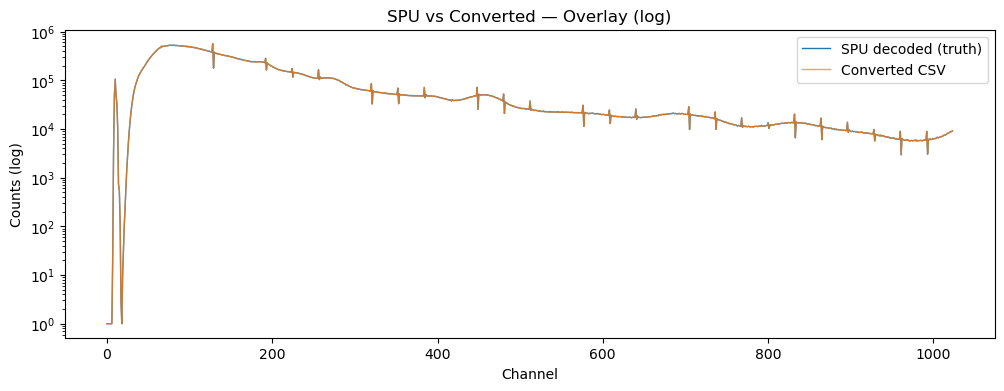

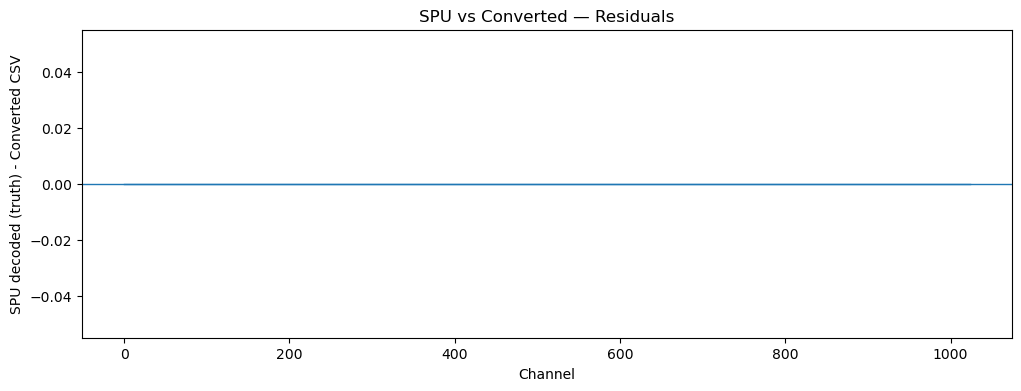


=== ALL TESTS PASSED ===

=== Verification summary ===
Total SPU files: 21
OK: 21
BAD: 0
PASS: processed_data appears to match data exactly for all .spu files.


In [110]:
# -----------------------------
# 
# -----------------------------

# 1) Convert entire tree (CLEARS processed_data first)
convert_data_tree(data_root="data", processed_root="processed_data", clear_processed_root=True)

# 2) Run single-file tests against your UCS-export sample
run_all_header_and_counts_tests(
    spu_path=spu_path,
    ucs_sample_csv=test_csv_path,
    out_converted_csv=Path("processed_data/_single_test_converted.csv"),
    make_plots=True
)

# 3) Verify whole processed tree vs raw tree (counts)
verify_processed_tree("data", "processed_data", max_plots=10, only_mismatches=True)